# This is our notebook

### Load Data

Here, we load the dataset in using the pandas built in library for reading through csv files. Below is the first 5 rows of the dataset printed to give an idea of the type of data we will be working with.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve,average_precision_score)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
from sklearn.metrics import balanced_accuracy_score


df = pd.read_csv("training_v2.csv")
df.head()


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


After loading in our data, we handle the missing values and clean it up by encoding categorical variables and define the features and target. Here, we also split the data into 80% training and 20% testing to simulate real-world unseen data.

In [4]:
# Drop ID-like columns (not useful for prediction)
df = df.drop(columns=["encounter_id", "patient_id"], errors="ignore")

# Handle missing values
# numeric fill
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical fill
cat_cols = df.select_dtypes(exclude=["number"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

df = pd.get_dummies(df, drop_first=True)

X = df.drop("hospital_death", axis=1)
y = df["hospital_death"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sub = X_train.sample(n = 8000, random_state = 42)
y_train_sub = y_train.loc[X_train_sub.index]

### Baseline Model: Perceptron
and graphs, confusion and pr graph

pr graph states as it recall increases, it looks for more and more patients who are likely to die, which includes more false positives(people who actually lived). recall increases, but the percision decreases. 

In [ ]:


perceptron_model = Pipeline([
    ("scaler", StandardScaler()),
    ("perc", Perceptron(max_iter=2000, tol=1e-3))
])

perceptron_model.fit(X_train, y_train)

perceptron_preds = perceptron_model.predict(X_test)

perceptron_scores = perceptron_model.decision_function(X_test)

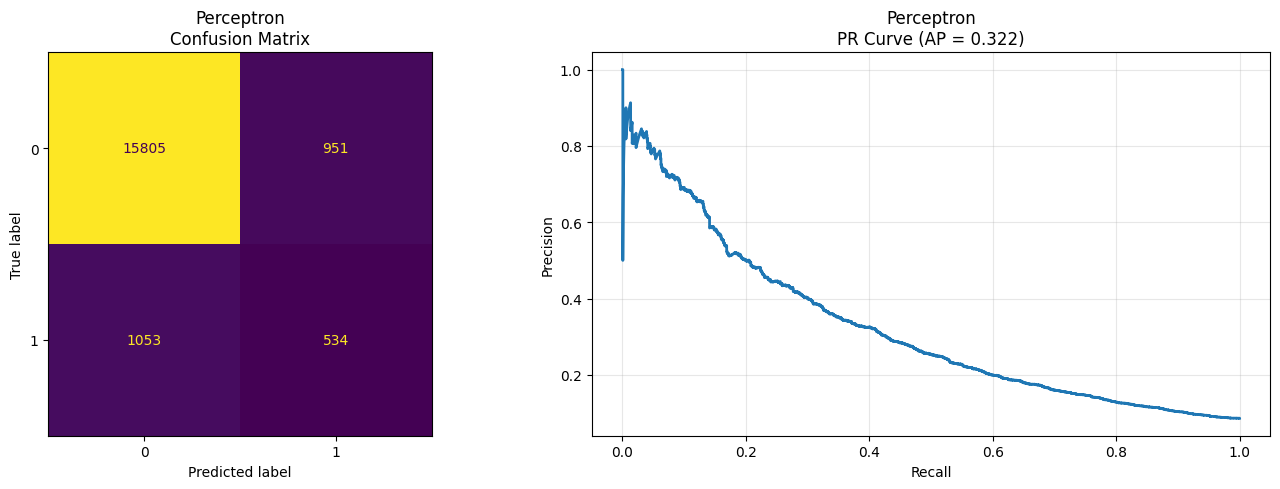

In [53]:
y_pred = perceptron_model.predict(X_test)
y_scores = perceptron_model.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Perceptron\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Perceptron\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### First Step Up: Basic SVM

A Support Vector Machine (SVM) with an RBF kernel was used to construct a nonlinear maximum-margin classifier. Given the complexity of the data, we figured this model would be a good starting point for our analysis and prediction of the relationship between these features and the morality rate.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

basic_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

basic_svm.fit(X_train_sub, y_train_sub)

basic_svm_preds = basic_svm.predict(X_test)
basic_svm_probs = basic_svm.predict_proba(X_test)[:, 1]

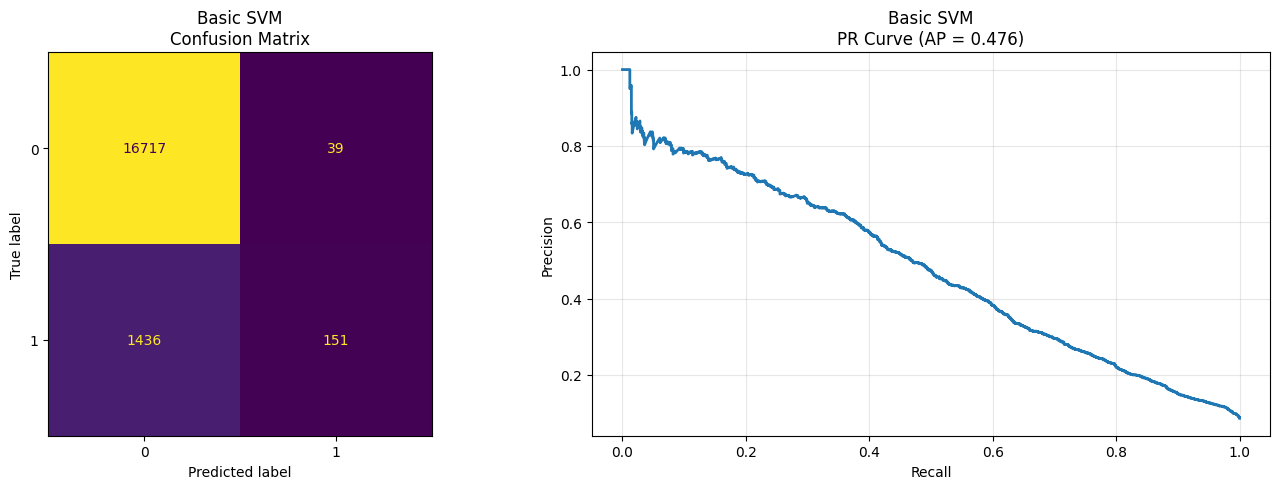

In [54]:
y_pred = basic_svm.predict(X_test)
y_scores = basic_svm.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Basic SVM\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Basic SVM\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()


### Linear SVM

In [ ]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=10000))
])

param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,              # reduced CV for speed
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


best_preds = best_model.predict(X_test)
accuracy = accuracy_score(y_test, best_preds)

print("Accuracy of best LinearSVC model:", accuracy)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'svm__C': 0.01, 'svm__class_weight': 'balanced'}
Best CV score: 0.8831888457492528
Accuracy of best LinearSVC model: 0.8166603063839066


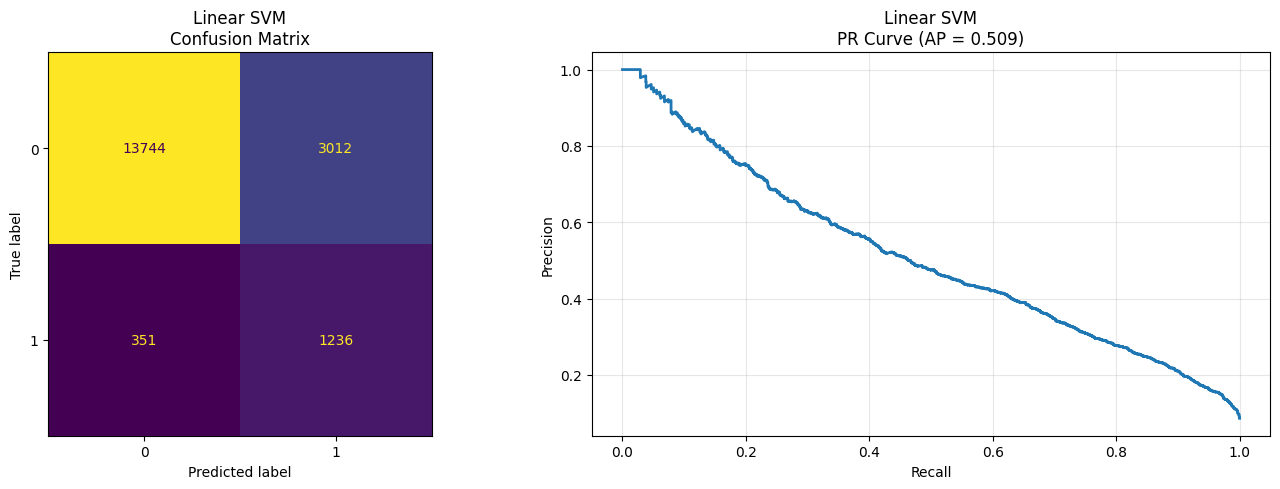

In [55]:
y_pred = best_model.predict(X_test)
y_scores = best_model.decision_function(X_test)


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Linear SVM\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Linear SVM\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### Decision Tree

Our non linear model - our other models are linear, this model is non linear, wanted to see the fit

In [ ]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5  # controls overfitting (important for medical data)
)

# Train
tree_model.fit(X_train, y_train)

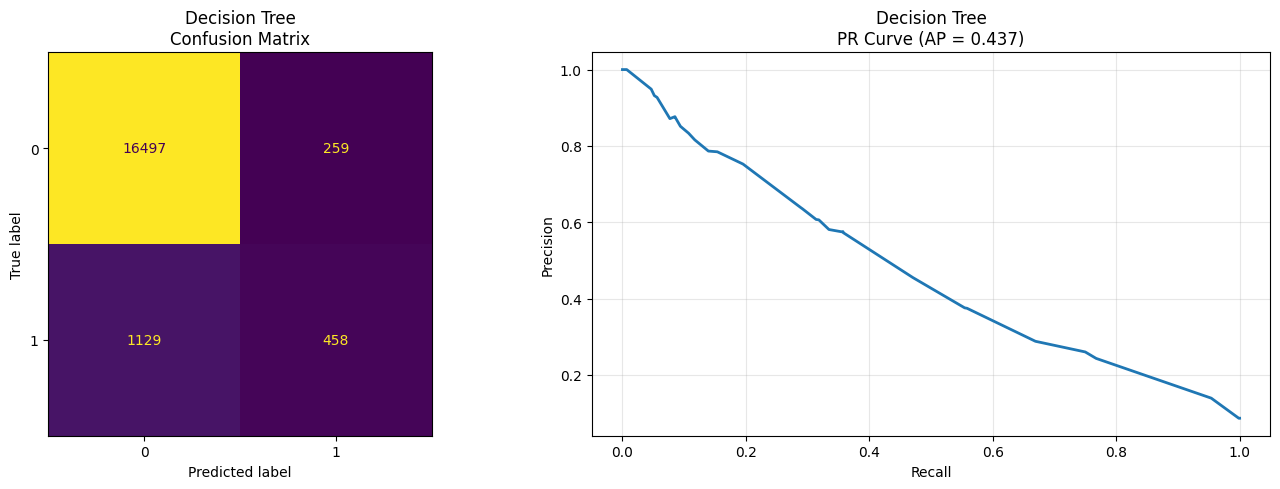

In [58]:
y_pred = tree_model.predict(X_test)
y_scores = tree_model.predict_proba(X_test)[:, 1]


# Create Side-by-Side Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# LEFT: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=axes[0], colorbar=False)

axes[0].set_title("Decision Tree\nConfusion Matrix")


# RIGHT: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

ap = average_precision_score(y_test, y_scores)

axes[1].plot(recall, precision, lw=2)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title(f"Decision Tree\nPR Curve (AP = {ap:.3f})")

axes[1].grid(alpha=0.3)


# Final Layout
plt.tight_layout()
plt.show()

### Accuracies of Our Models

After creating these models, we decided to test them and compare their accuracies. The performance metric we used for comparison was the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) since it's utilized for binary classification models. This fit perfect with the goal of determining morality (live vs death) through the data. It focuses on separation such that it doesn't have a Pass/Fail cutoff. Instead, it measures how well the model ranks patients. An AUC of 0.88 means that if you randomly pick one patient who died and one who survived, there is an 88% chance the model will give the patient who died a higher risk score.

We chose ROC-AUC as our primary metric because accuracy can be misleading in a hospital setting where deaths are relatively rare. We needed a metric that proved our model could effectively prioritize high-risk patients over low-risk ones, ensuring that the 'signal' of a declining patient wasn't lost in the 'noise' of the surviving majority.

###
To analyze the accuries we first wanted to understan what our seperation of classieiers was in the data, we wanted to understand the ratio of lived to died. 

In [59]:
print("Total lived:", np.sum(y_test == 0)) 
print("Total died:", np.sum(y_test == 1))

Total lived: 16756
Total died: 1587


In [60]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)


    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AP Score": average_precision_score(y_test, y_scores),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_scores)
    }

# Evaluate all models
results = {}

results["Regular SVM"] = evaluate_model(basic_svm, X_test, y_test)
results["Linear SVM (tuned)"] = evaluate_model(best_model, X_test, y_test)
results["Perceptron"] = evaluate_model(perceptron_model, X_test, y_test)
results["Decision Tree"] = evaluate_model(tree_model, X_test, y_test)

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print(results_df)

                    Accuracy  F1 Score  AP Score  Balanced Accuracy  ROC-AUC
Regular SVM           0.9196    0.1699    0.4763             0.5464   0.8525
Linear SVM (tuned)    0.8167    0.4237    0.5087             0.7995   0.8853
Perceptron            0.8907    0.3477    0.3222             0.6399   0.7417
Decision Tree         0.9243    0.3976    0.4374             0.6366   0.8453


### Analysis of Model Approach:

In medical prediction:
Accuracy can look high even if the model is useless clinically
ROC-AUC is more stable and meaningful for risk prediction
F1 is critical for detecting rare events (death)

We initially started with a Support Vector Machine since we figured thatdealing with complex ICU data would require a complex model to approporiately capture the life and death nuances of patient care. We even tried tuning the hyperparameters with the thought that a more 'rigourous' model would perform better.

However, the results surprised us. Not only did our 'Basic' SVM perform better than the 'Tuned' version, but when we tried to reduce the feature space to simplify the model, our accuracy plummeted to a 0.62 AUC. This is barely better than a coin flip. Thus, we concluded two things:

- Complexity isn't always better: Over-tuning led to overfitting.

- Clinical data is rich: You cannot predict mortality by looking at just a few variables; you need the full clinical picture.


Seeing that these more complex models were struggling with the sheer size of our training data of nearly 92,000 patients, we pivoted back to a Logistic Regression. We realized that in the ICU, clinical markers often have a direct, linear relationship with risk. By using a simpler model, we were able to train on the entire dataset instead of a small sample.

After implementing a Logistic Regression model, we were able to achive our highest ROC-AUC of 0.8832, effectively outperforming the complex SVMs while being faster and more interpretable.

Upon further deliberation, we concluded that SVMs can be very sensitive to imbalance, and if it doesn't see enough examples of the minority class (ie patients who passed away), it struggles to find a good boundary. The Basic SVM beat the Tuned SVM because of the overfitting. This caused the tuned model to try too hard to fit the training data perfectly, which made it perform worse on the test data. Especially since it was trained on only about 10% of the patients, it had less 'experience' to effectively learn from.

While SVM is a more complex nonlinear model, the Logistic Regression performed best. This suggests that the predictors for hospital mortality in this dataset have a strong linear relationship with the outcome, and the model benefited significantly from being trained on the full 91k-row dataset rather than a subset.

### Final Model Analysis

With our best-performing model (Logistic Regression, AUC: 0.8832) finalized and validated, we transitioned to the deployment phase. We applied the model to the unlabeled dataset (unseen data) to generate mortality risk probabilities for new patients. To ensure consistency, we performed the exact same preprocessing steps, like handling missing values and aligning features, so the model could interpret the data correctly. The resulting file represents our final clinical predictions, ranking patients by their likelihood of needing urgent intervention.


In [19]:
unlabeled_df = pd.read_csv("unlabeled.csv")

submission_ids = unlabeled_df['encounter_id']

unlabeled_df = unlabeled_df.drop(columns=["encounter_id", "patient_id"], errors="ignore")
train_medians = df[num_cols].median()
unlabeled_df[num_cols] = unlabeled_df[num_cols].fillna(train_medians)

unlabeled_df[cat_cols] = unlabeled_df[cat_cols].fillna("Unknown")
X_unlabeled = pd.get_dummies(unlabeled_df, drop_first = True)

X_unlabeled = X_unlabeled.reindex(columns = X.columns, fill_value = 0)

final_probs = baseline_model.predict_proba(X_unlabeled)[:, 1]

submission = pd.read_csv("solution_template.csv")

submission["hospital_death"] = final_probs
submission.to_csv("my_final_predictions.csv", index = False)

fin = pd.read_csv("my_final_predictions.csv")
fin.head()

,encounter_id,hospital_death
0,2,0.044505
1,5,0.010659
2,7,0.018282
3,8,0.104474
4,10,0.245887
